Implement K-Means clustering on sales_data_sample.csv dataset. Determine the number of clusters
using the elbow method.
Dataset link :
https://www.kaggle.com/datasets/kyanyoga/sample-sales-data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("D:/KAUSTUBH/LP3 Final/sales_data_sample.csv", encoding="latin")

df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [3]:
# Select relevant numeric features for clustering
df = df[['QUANTITYORDERED', 'PRICEEACH', 'SALES']]
df

,QUANTITYORDERED,PRICEEACH,SALES
0,30,95.70,2871.00
1,34,81.35,2765.90
2,41,94.74,3884.34
3,45,83.26,3746.70
4,49,100.00,5205.27
...,...,...,...
2818,20,100.00,2244.40
2819,29,100.00,3978.51
2820,43,100.00,5417.57
2821,34,62.24,2116.16


In [4]:
df = df.dropna()

In [5]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df.values)

In [6]:
# Determine the optimal number of clusters using the elbow method
inertia = []
K = range(1, 11)  # Check for 1 to 10 clusters

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

### What is elbow method? Significance of Elbow method.
### **Elbow Method in K-Means Clustering**

The **Elbow Method** is a heuristic used to determine the optimal number of clusters (denoted as **K**) for K-Means clustering. It is based on the idea of finding a point at which adding more clusters doesn't significantly improve the performance of the model. This point is referred to as the "elbow," where the rate of decrease in the **within-cluster sum of squares (WCSS)** slows down, forming an elbow-like shape in the graph.

#### **How the Elbow Method Works**

1. **Run K-Means for Different K Values**:
   - Start by running the K-Means algorithm for a range of values for **K**, starting from **K = 1** and increasing it step by step (e.g., K = 1, 2, 3, …).
   - For each value of K, calculate the **WCSS** (within-cluster sum of squares) or **SSE** (sum of squared errors).

2. **Plot WCSS (or SSE) Against K**:
   - Plot the **WCSS** on the y-axis and the **number of clusters (K)** on the x-axis.
   - The WCSS decreases as K increases because the more clusters you have, the more precise the fit will be (fewer data points in each cluster, and hence less variation within each cluster).

3. **Look for the Elbow Point**:
   - As you increase the number of clusters, the **WCSS** will decrease rapidly at first, but after a certain point, the rate of decrease will slow down and level off.
   - The "elbow" is the point where this rate of decrease sharply flattens. This indicates that adding more clusters does not significantly reduce the error or improve the model.

4. **Choose the Optimal K**:
   - The value of **K** at the elbow is considered the optimal number of clusters. It strikes a balance between **underfitting** (too few clusters) and **overfitting** (too many clusters).
   
---

### **Significance of the Elbow Method**

- **Helps Determine Optimal K**: The Elbow Method provides a visual and intuitive way to select the right number of clusters without requiring domain knowledge or arbitrary choices.
  
- **Minimizes Overfitting and Underfitting**:
  - **Underfitting**: If K is too small, clusters may be too broad, leading to poor modeling of the data.
  - **Overfitting**: If K is too large, clusters may become too fine-grained, overfitting the model to the noise in the data, making it less generalizable to unseen data.

- **Balances Complexity and Accuracy**: The elbow point represents a trade-off where adding more clusters leads to diminishing returns in terms of improving the clustering performance. After the elbow, the gain in clustering accuracy becomes marginal, and the model complexity (with more clusters) increases.

---

### **Example of the Elbow Method**:

Let's say you're working with a dataset, and you want to use K-Means to cluster it. Here’s what the Elbow Method would look like in practice:

1. **Run K-Means for Different K Values**: You run the algorithm for K = 1 to K = 10.
   
2. **Plot the WCSS for Each K**: You plot the WCSS against K, and you observe a rapid decrease in WCSS as you go from K = 1 to K = 3, but then the curve starts flattening as K increases further.

3. **Identify the Elbow**: The point where the curve changes from a steep slope to a gentle slope (the "elbow") is typically around K = 3 or K = 4. This suggests that 3 or 4 clusters may be optimal for your dataset.

4. **Select K**: Based on the elbow, you would choose K = 3 or K = 4 as the ideal number of clusters.

---

### **Other Methods to Determine Optimal K**:
While the Elbow Method is commonly used, there are other techniques that may help in determining the optimal number of clusters:

1. **Silhouette Score**: Measures how similar each data point is to its own cluster compared to other clusters. The optimal K is the one that maximizes the average silhouette score.

2. **Gap Statistic**: Compares the performance of the clustering model to random clustering, and the optimal K is where the gap between the two is largest.

3. **Cross-Validation**: Some methods use cross-validation techniques to assess how well a clustering solution generalizes to unseen data.


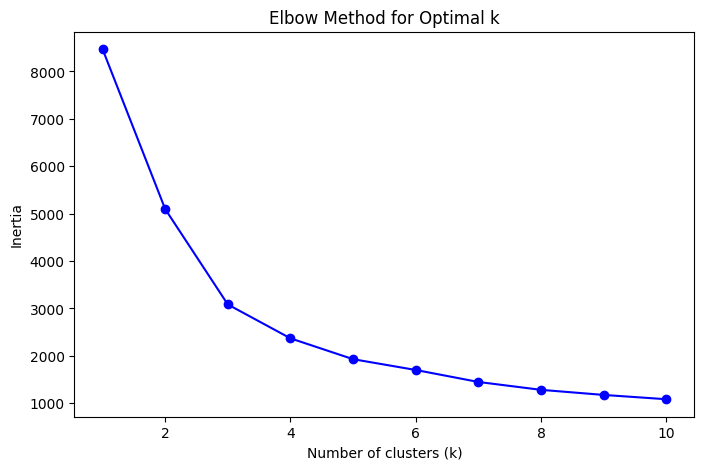

In [7]:
# Plot the elbow graph
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [8]:
optimal_k = 3  # Set this to the elbow point you observed
kmeans = KMeans(n_clusters=optimal_k, random_state=0)
kmeans.fit(scaled_data)

KMeans(n_clusters=3, random_state=0)

In [9]:
print("Cluster Centers: \n", kmeans.cluster_centers_)

Cluster Centers: 
 [[ 1.14899965e-03 -1.32175214e+00 -8.41918812e-01]
 [-7.92678932e-01  5.52789374e-01 -2.55710107e-01]
 [ 8.95650592e-01  6.39987864e-01  1.09527704e+00]]


In [10]:
df['Cluster'] = kmeans.labels_  # Assign the predicted cluster labels to the original data

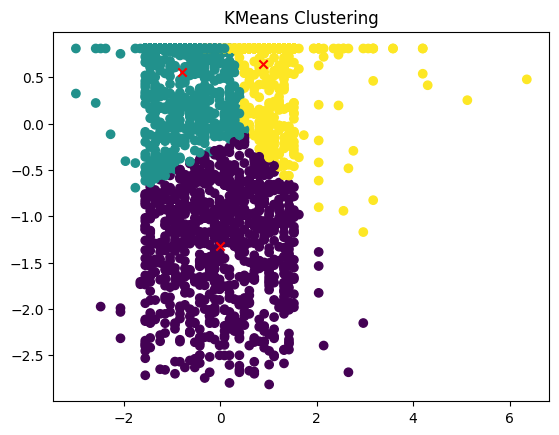

In [11]:
plt.scatter(scaled_data[:, 0], scaled_data[:, 1], c=kmeans.labels_, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], color='red', marker='x')
plt.title('KMeans Clustering')
plt.show()

### **K-Means Clustering**

**K-Means Clustering** is a popular **unsupervised machine learning** algorithm used for **grouping similar data points** into clusters. The goal is to partition a set of data points into a predefined number of clusters (denoted as **K**) such that the data points in each cluster are more similar to each other than to those in other clusters.

#### **Key Concepts**:
- **Unsupervised Learning**: The algorithm doesn't require labeled data. It tries to group the data based on inherent similarities.
- **Centroid**: A **centroid** is the central point of a cluster, typically represented as the mean of all points in the cluster.
- **Distance Measure**: K-Means typically uses **Euclidean distance** (straight-line distance between points) to measure similarity between data points and centroids.

### **How K-Means Clustering Works**

The K-Means algorithm follows a simple iterative process:

#### **Step-by-Step Process**:

1. **Initialization**:
   - **Choose K**: The user must specify the number of clusters (K) in advance.
   - **Initialize Centroids**: K initial centroids are selected randomly from the dataset. These centroids can either be chosen randomly from data points or selected using more sophisticated methods (like K-Means++).

2. **Assigning Data Points to Clusters**:
   - For each data point in the dataset, calculate the **distance** from that point to each of the K centroids.
   - Assign the point to the cluster whose centroid is the closest (using the **Euclidean distance** or other distance measures).

3. **Recalculate Centroids**:
   - After all points have been assigned to clusters, recalculate the centroids for each cluster. This is done by taking the **mean** of all points within each cluster:
   $$
   \text{New Centroid} = \frac{1}{n} \sum_{i=1}^{n} x_i
   $$
   where x_i are the data points in the cluster.

4. **Repeat**:
   - Repeat Steps 2 and 3 until the centroids no longer change (or the changes are very small), or until a predefined number of iterations is reached. This means the algorithm has converged.

5. **Final Output**:
   - The result is a set of K clusters with data points assigned to the clusters based on the proximity to the centroids.

### **Mathematical Formula for Euclidean Distance**:
To determine which centroid is closest to a data point, we typically use the **Euclidean distance**:
$$
d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}
$$
Where:
- x and y  are the coordinates of two points (data points or centroids).
-  n is the number of features (dimensions) in the data.

### **Example**:
Let's say we have a simple 2D dataset and want to cluster it into **2 clusters (K=2)**:

1. **Initialize**: Randomly select two points as centroids.
2. **Assign points to clusters**: Assign each data point to the nearest centroid.
3. **Recalculate centroids**: Compute the mean of the points in each cluster to find the new centroids.
4. **Repeat**: Reassign points to clusters based on the updated centroids and recalculate centroids again.

This process continues until the centroids stabilize (do not change) or a set number of iterations is reached.

### **Key Points to Understand in K-Means**:

- **K (number of clusters)**: The user must specify how many clusters they want the algorithm to find. However, the choice of K can significantly impact the results, and finding the optimal K is not always straightforward.
  
- **Centroids**: The center point of each cluster. The K-Means algorithm iteratively adjusts the centroids to find the best grouping of data points.

- **Distance metric**: K-Means typically uses Euclidean distance to measure how close each data point is to the centroids, but other distance metrics can also be used in some variations.

---

### **Advantages of K-Means**:

1. **Simple and Efficient**: K-Means is easy to implement and computationally efficient, especially with large datasets.
2. **Scalability**: K-Means works well with large datasets as it scales linearly with the number of data points.
3. **Clear Results**: The algorithm produces clear clusters, which are easy to interpret.

---

### **Disadvantages of K-Means**:

1. **Choosing K**: The number of clusters (K) must be chosen in advance, which can be tricky without domain knowledge. If the wrong K is chosen, the clustering results can be poor.
2. **Sensitivity to Initialization**: K-Means can get stuck in local minima. The initial placement of centroids can impact the final clusters, leading to different results in different runs. To mitigate this, multiple initializations are often used (K-Means++).
3. **Sensitivity to Outliers**: K-Means is sensitive to outliers, as outliers can distort the position of the centroids. If there are noisy data points or outliers, they can affect the clustering.
4. **Assumes Spherical Clusters**: K-Means assumes that clusters are **spherical** and have similar sizes, which may not be the case in real-world data.
5. **Works only for numerical data**: K-Means requires numeric data because it relies on distance calculations, so categorical data must first be converted to a numerical format.

---

### **Applications of K-Means**:

1. **Customer Segmentation**: Grouping customers based on purchasing behavior or demographics for targeted marketing.
2. **Image Compression**: Reducing the number of colors in an image by clustering pixel values into a smaller number of clusters.
3. **Document Clustering**: Grouping similar documents or articles based on content.
4. **Anomaly Detection**: Identifying data points that do not fit into any cluster as potential anomalies.
5. **Biology**: Classifying gene expression data into different groups based on patterns of gene activity.

### Is kmeans supervised? Justify the answer.
**No, K-Means is not a supervised learning algorithm.** 

### **Justification:**

K-Means is an **unsupervised learning** algorithm because it does not require labeled data to train the model. Here's why:

1. **No Labeled Data**:
   - In supervised learning, the model is trained on **labeled data**, meaning that each input data point has a corresponding target label (e.g., class or value). For example, in a classification problem, the model is trained with data where the correct class label for each instance is provided.
   - **K-Means clustering**, on the other hand, groups data points into clusters based on their **similarity** (usually using distance metrics like Euclidean distance). It does not rely on any labels or target outputs for training. The algorithm simply attempts to find structure in the data by grouping similar instances together.

2. **Goal of K-Means**:
   - The goal of **K-Means clustering** is to **partition data into K clusters** such that the points within each cluster are as similar as possible. The algorithm does this by iteratively updating centroids (the "center" of each cluster) and assigning data points to the nearest centroid. There is no external guidance or labeled output involved in this process.
   - In contrast, in supervised learning (e.g., regression or classification), the goal is to **predict a specific output** (a label or value) for each input based on known relationships from the training data.

3. **Learning Process**:
   - K-Means works by finding the **structure in the data** itself. It uses a method called **clustering**, where it groups data points that are close to each other in feature space. It doesn't need any labels to guide this grouping. 
   - In supervised learning, the model learns to **map inputs to known labels** using labeled data to predict outcomes or classify new data points.